### Config

In [ ]:
from code.v1_utils import process_remote, process_insitu, fuse_datasets
from code.v1_preparation import slice_by_dates, preprocess_for_ML_chrono, preprocess_for_ML_chrono_inverse
from code.v1_training import tune_model, train_model, evaluate_model, apply_model
from code.v1_plotting import plot_pred_vs_real, plot_timeseries_results
from code.v1_shap_analysis import calculate_shap_values, plot_shap

import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

/opt/miniconda3/envs/ML/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# PCA
def scale_and_apply_PCA(df, feature_columns, n_components=2, random_state=42):
    data = df.copy()
    subset = data[feature_columns]

    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(subset)

    pca_model = PCA(n_components=n_components, random_state=random_state)
    pc = pca_model.fit_transform(scaled_features)

    pc_names = [f'PC_{i+1}' for i in range(n_components)]

    pca_df = pd.DataFrame(
        data=pc, 
        columns=pc_names, 
        index=data.index
    )
    return pca_df, pca_model

def evaluate_pca_performance(pca_model):
    explained_variance = pca_model.explained_variance_ratio_ * 100
    total_variance = np.sum(explained_variance)

    print("--- PCA Evaluation ---")
    for i, variance in enumerate(explained_variance):
        print(f"Component {i+1} explains: {variance:.2f}% of the variance")
    
    print(f"Total information retained: {total_variance:.2f}%")
    print("----------------------")

def get_pca_loadings(pca_model: PCA, feature_columns: list) -> pd.DataFrame:

    # Extract the components matrix from the fitted model
    # Each row is a principal component, each column is an original feature
    loadings_matrix = pca_model.components_
    
    # Transpose the matrix so features become rows and components become columns
    loadings_transposed = np.transpose(loadings_matrix)
    
    # Generate dynamic column names for the components (e.g., 'PC_1', 'PC_2')
    n_components = loadings_matrix.shape[0]
    pc_names = [f'PC_{i+1}' for i in range(n_components)]
    
    # Create a dataframe for easy visualization and interpretation
    loadings_df = pd.DataFrame(
        data=loadings_transposed,
        columns=pc_names,
        index=feature_columns
    )
    return loadings_df

# CROSS CORRELATIONS
def difference_time_series(df):
    dif_df = df.copy()
    dif_df = dif_df.diff()
    dif_df = dif_df.dropna()
    return dif_df

def analyze_cross_correlations(df, target_col, feature_cols, max_lag):
    data = df.copy()
    results = []

    for feature in feature_cols:
        for lag in range(-max_lag, max_lag+1):
            shifted_feature = data[feature].shift(lag)
            correlation = data[target_col].corr(shifted_feature)

            if lag > 0:
                direction = 'past'
                display_lag = f'past_{lag}'
            elif lag <0:
                direction = 'future'
                display_lag = f'future_{lag}'
            else:
                direction = 'same_day'
                display_lag = 'lag_0'

            results.append({
                'feature': feature,
                'direction': direction,
                'lag_value': lag,
                'lag_name': display_lag,
                'correlation': correlation,
                'abs_correlation': abs(correlation)
            })
    
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(
        by=['feature', 'abs_correlation'], 
        ascending=[True, False]
    ).reset_index(drop=True)

    return results_df

In [3]:
remote_features = [
    'ndvi_mean',
    'gndvi_mean',
    'ndwi_mean',
    'mndwi_mean',
    'ndmi_mean',
    'ndmi2_mean',
    'str1_mean',
    'str2_mean',
    'brightness_mean',
    'greenness_mean',
    'wetness_mean'
]

target1 = ['SDH1PS01_gw-depth_m']

# List of variables to exclude from z-score filtering
no_outlier_check = ['ATMOS41_precipitation_mm']

### Model training

#### North site

In [4]:
# DATA PREPROCESSING
remote_df1 = process_remote(
    filepath='../data/processed/satellites/SDH1_S2_20m_2015-10_2026-06.csv',
    duplicates=True, reindex=True, 
    outliers=True,
    stats=True,
    filter_cols=True, remote_cols=remote_features,
    interpolation=True,
    smooth=True, window_length=7
)
remote_df1 = slice_by_dates(df=remote_df1, startDate='2024-05-22', endDate='2026-05-14',)

insitu_df1 = process_insitu(
    filepath='../data/processed/in-situ/SDH1_daily-insitu-data.csv',
    filter_cols=True, insitu_cols=target1,
    duplicates=True, reindex=True, 
    outliers=True, ignore_vars=None, 
    interpolation=False, 
    smooth=False
)

--- PCA Evaluation ---
Component 1 explains: 65.43% of the variance
Component 2 explains: 31.83% of the variance
Total information retained: 97.26%
----------------------
                     PC_1      PC_2
ndvi_mean        0.331062 -0.201779
gndvi_mean       0.345735 -0.183065
ndwi_mean       -0.345735  0.183065
mndwi_mean      -0.075644  0.521635
ndmi_mean        0.094449  0.513603
ndmi2_mean       0.185792  0.459017
str1_mean        0.364176  0.041367
str2_mean        0.355513  0.124402
brightness_mean -0.358722  0.104336
greenness_mean   0.366490 -0.051323
wetness_mean     0.283128  0.339064


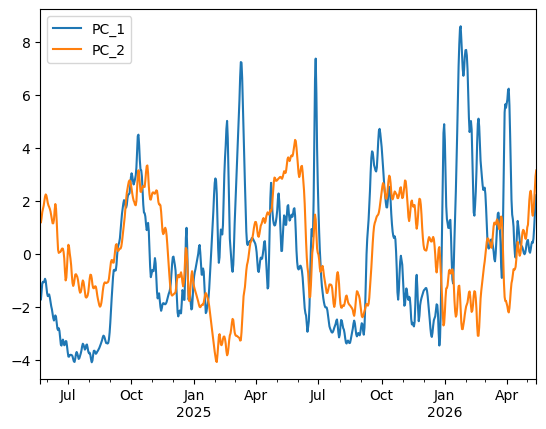

In [5]:
pca_df1, pca_model1 = scale_and_apply_PCA(remote_df1, remote_features, 2, 42)
evaluate_pca_performance(pca_model1)
pca_df1.plot()
loadings = get_pca_loadings(pca_model1, remote_features)
print(loadings.head(20))

In [6]:
fused_df1 = fuse_datasets(
    insitu=insitu_df1, remote=pca_df1, 
    startDate='2024-05-22', endDate='2026-05-14',
    dropNaN=True, 
    addTime=False, 
    addLags=False
)
dif_df = difference_time_series(fused_df1)
cross = analyze_cross_correlations(dif_df, 'SDH1PS01_gw-depth_m', ['PC_1', 'PC_2'], 30)
cross

,feature,direction,lag_value,lag_name,correlation,abs_correlation
0,PC_1,same_day,0,lag_0,0.339562,0.339562
1,PC_1,future,-1,future_-1,0.315343,0.315343
2,PC_1,past,1,past_1,0.287739,0.287739
3,PC_1,future,-2,future_-2,0.241357,0.241357
4,PC_1,past,2,past_2,0.182782,0.182782
...,...,...,...,...,...,...
117,PC_2,past,28,past_28,-0.016559,0.016559
118,PC_2,future,-9,future_-9,0.011620,0.011620
119,PC_2,future,-21,future_-21,-0.006806,0.006806
120,PC_2,past,18,past_18,-0.006622,0.006622


In [7]:
fused_df1 = fuse_datasets(
    insitu=insitu_df1, remote=pca_df1, 
    startDate='2024-05-22', endDate='2026-05-14',
    dropNaN=False, 
    addTime=True, 
    addLags=True, laggedFeatures=['PC_1', 'PC_2'], nLags=3, intervalLags=1
)

Chronological split applied at: 2025-05-17
Training samples: 359 | Testing samples: 360
{'max_depth': 15, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 100}
Model performance (testing):
 {'RMSE': 0.0508, 'MAE': 0.0396, 'R2': 0.7686, 'PBIAS': np.float64(2.6327), 'MSE': 0.0026}
Model performance (training):
 {'RMSE': 0.0068, 'MAE': 0.0046, 'R2': 0.9975, 'PBIAS': np.float64(-0.0128), 'MSE': 0.0}


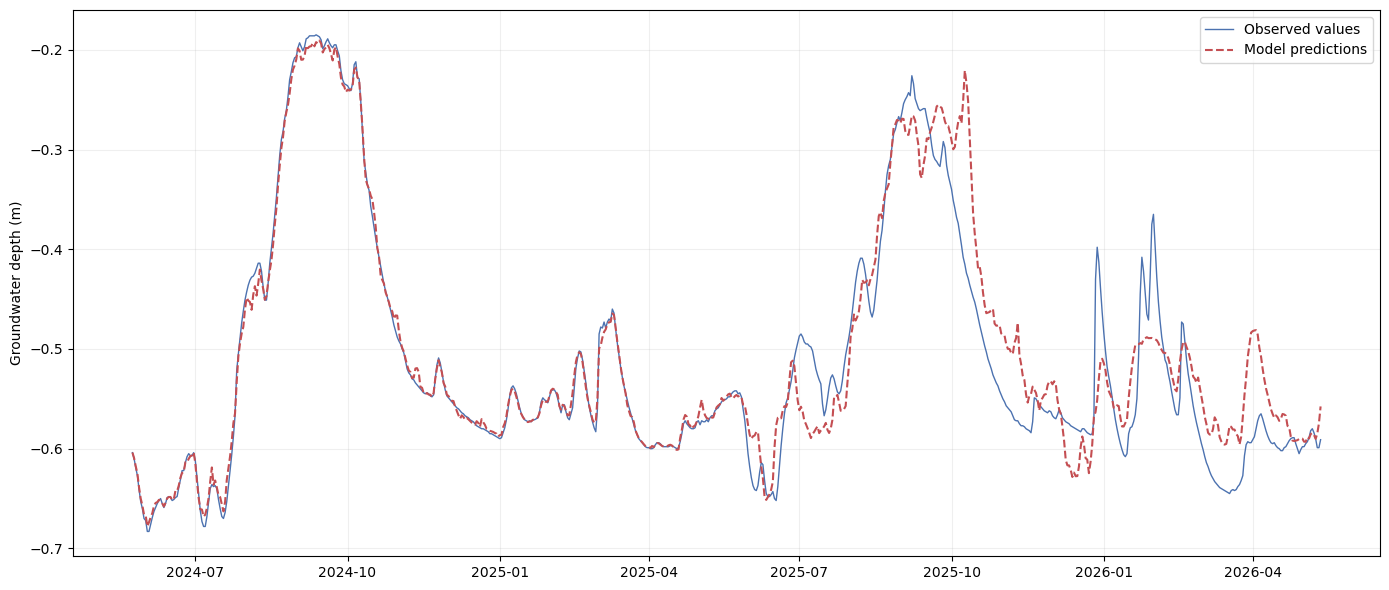

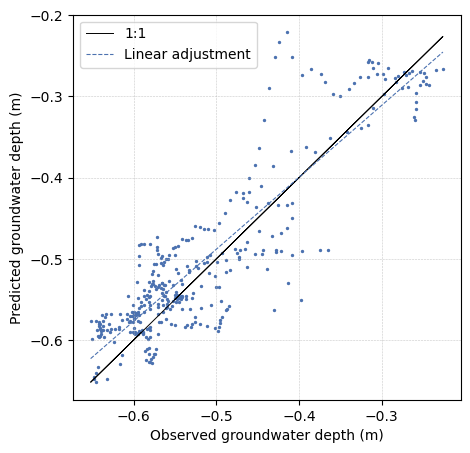

In [8]:
# DATA SPLIT
X_train_scaled1, X_test_scaled1, y_train1, y_test1, scaler1, test_dates1 = preprocess_for_ML_chrono(
    df=fused_df1, 
    target=target1, 
    train_size=0.5
    )
# TUNE HYPERPARAMETERS
best_params = tune_model(
    X_train_scaled=X_train_scaled1, 
    y_train=y_train1
    )
# MODEL TRAINING
model1 = train_model(
    X_train_scaled=X_train_scaled1, 
    y_train=y_train1,
    best_params=best_params,
    random_state=42
    )
# MODEL EVALUATION
y_pred_test1, y_pred_train1, results_test1, results_train1 = evaluate_model(
    model=model1,
    X_test_scaled=X_test_scaled1,
    y_test=y_test1,
    X_train_scaled=X_train_scaled1,
    y_train=y_train1
    )
# MODEL APLICATION
applied1 = apply_model(
    df=fused_df1,
    target=target1,
    scaler=scaler1,
    model=model1
    )
# PLOTTING
plot_timeseries_results(df=applied1)
plot_pred_vs_real(y_test=y_test1, y_pred=y_pred_test1)

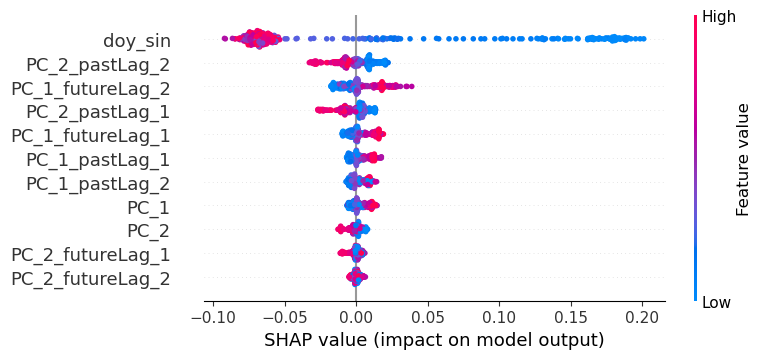

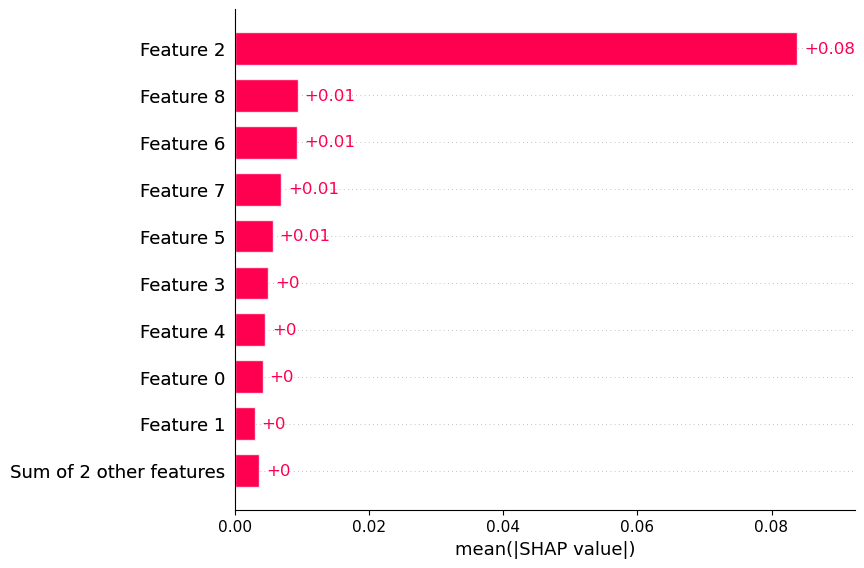

In [9]:
# SHAP
headings = fused_df1.drop(columns=target1[0]).columns
shap_values = calculate_shap_values(model1, X_test_scaled1)
plot_shap(shap_values, X_test_scaled1, headings)

### Model application

#### North site

##### Sentinel

In [10]:
remote_df1_past = process_remote(
    filepath='../data/processed/satellites/SDH1_S2_20m_2015-10_2026-06.csv',
    duplicates=True, reindex=True, 
    outliers=True,
    stats=True,
    filter_cols=True, remote_cols=remote_features,
    interpolation=True,
    smooth=True, window_length=7
)
pca_df1_past, pca_model1_past = scale_and_apply_PCA(
    df=remote_df1_past, 
    feature_columns=remote_features, 
    n_components=2, 
    random_state=42
    )
evaluate_pca_performance(pca_model1_past)

fused_df1_past = fuse_datasets(
    insitu=insitu_df1, remote=pca_df1_past, 
    startDate='2016-05-14', endDate='2026-05-14',
    dropNaN=False, 
    addTime=True, 
    addLags=True, laggedFeatures=['PC_1', 'PC_2'], nLags=3, intervalLags=1
)


--- PCA Evaluation ---
Component 1 explains: 61.36% of the variance
Component 2 explains: 34.18% of the variance
Total information retained: 95.54%
----------------------


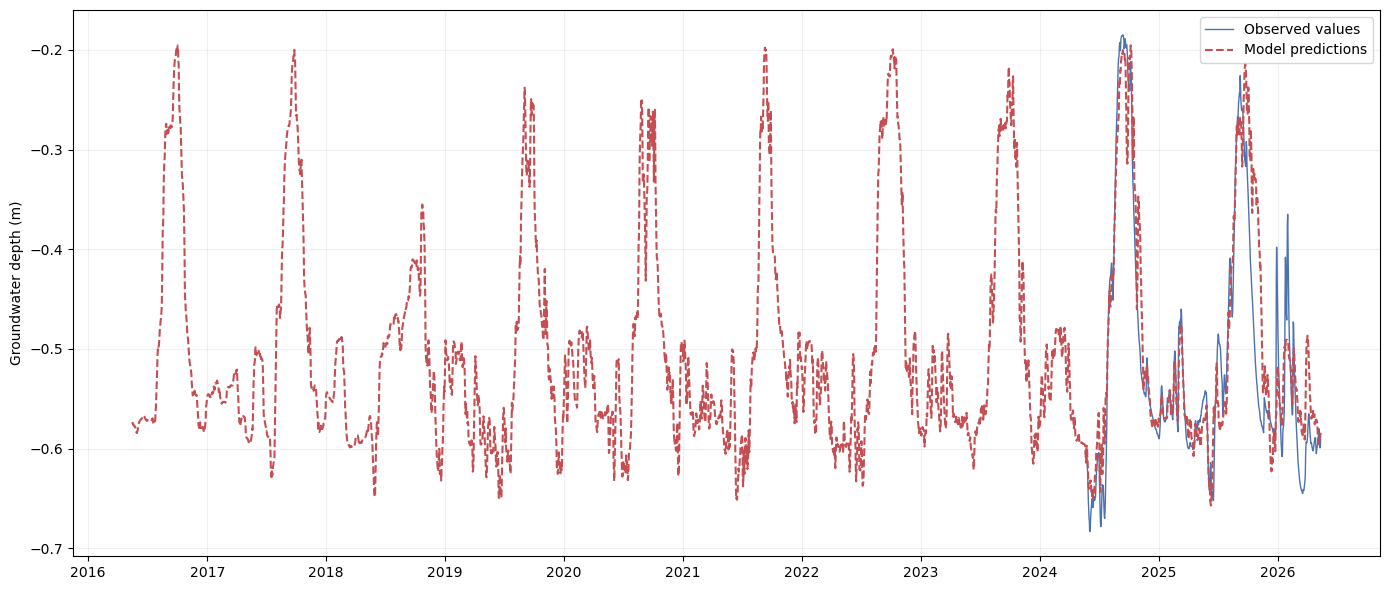

In [11]:
# MODEL APLICATION
applied1_past = apply_model(
    df=fused_df1_past,
    target=target1,
    scaler=scaler1,
    model=model1
    )

# PLOTTING
plot_timeseries_results(df=applied1_past)

##### Landsat

--- PCA Evaluation ---
Component 1 explains: 53.11% of the variance
Component 2 explains: 31.47% of the variance
Total information retained: 84.58%
----------------------


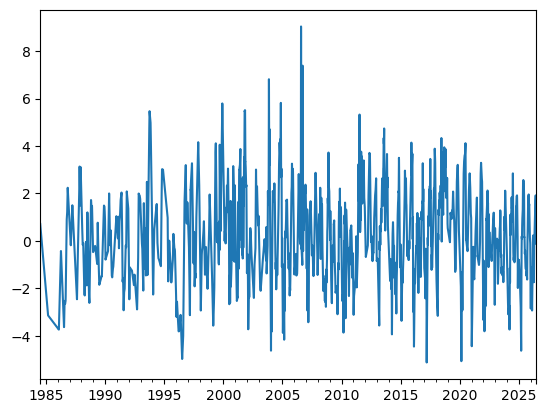

In [12]:
remote_L_df1_past = process_remote(
    filepath='../data/processed/satellites/SDH1_L_30m_1984-07_2026-06.csv',
    duplicates=True, reindex=True, 
    outliers=True,
    stats=True,
    filter_cols=True, remote_cols=remote_features,
    interpolation=True,
    smooth=True, window_length=7
)
#remote_L_df1_past = slice_by_dates(remote_L_df1_past, '2024', '2026')

pca_L_df1_past, pca_L_model1_past = scale_and_apply_PCA(
    df=remote_L_df1_past, 
    feature_columns=remote_features, 
    n_components=2, 
    random_state=42
    )
evaluate_pca_performance(pca_L_model1_past)
# El desempeño del PCA disminuye al añadir mas años hacia el pasado.
# Sospecho que es por la interpolacion en años con pocos registros
pca_L_df1_past['PC_2'].plot()

fused_L_df1_past = fuse_datasets(
    insitu=insitu_df1, remote=pca_L_df1_past, 
    startDate='1986-01-01', endDate='2026-05-14',
    dropNaN=False, 
    addTime=True, 
    addLags=True, laggedFeatures=['PC_1', 'PC_2'], nLags=3, intervalLags=1
)

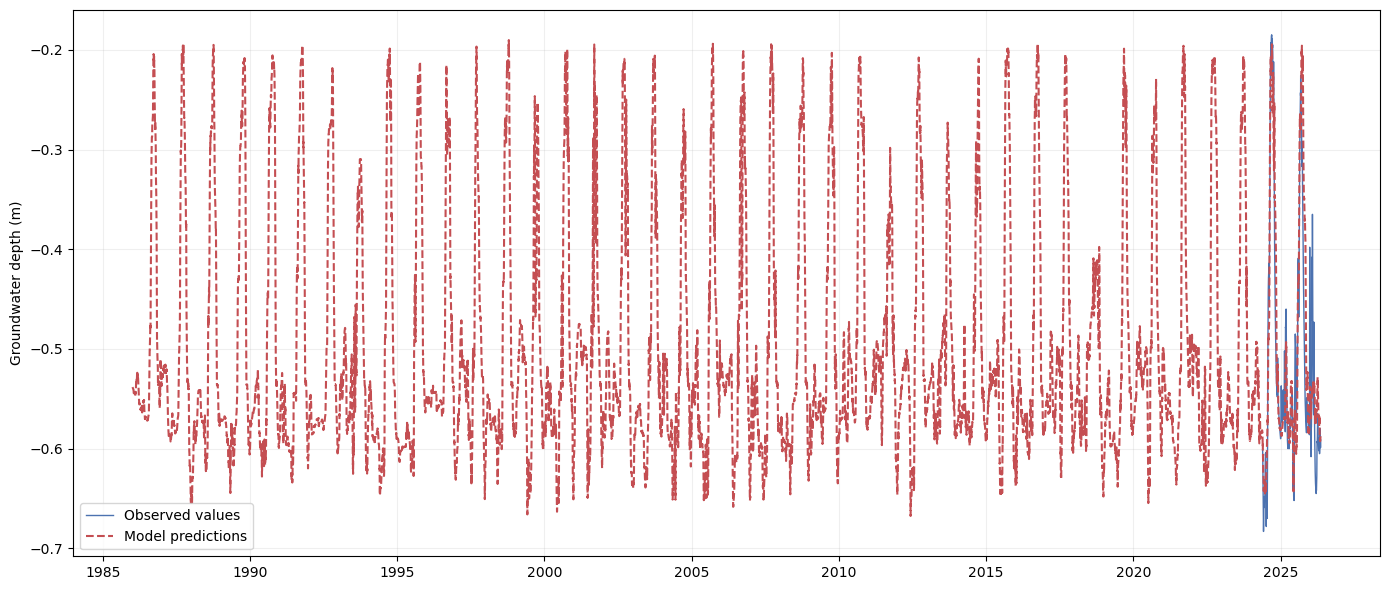

In [13]:
# MODEL APLICATION
applied1_L_past = apply_model(
    df=fused_L_df1_past,
    target=target1,
    scaler=scaler1,
    model=model1
    )

# PLOTTING
plot_timeseries_results(df=applied1_L_past)

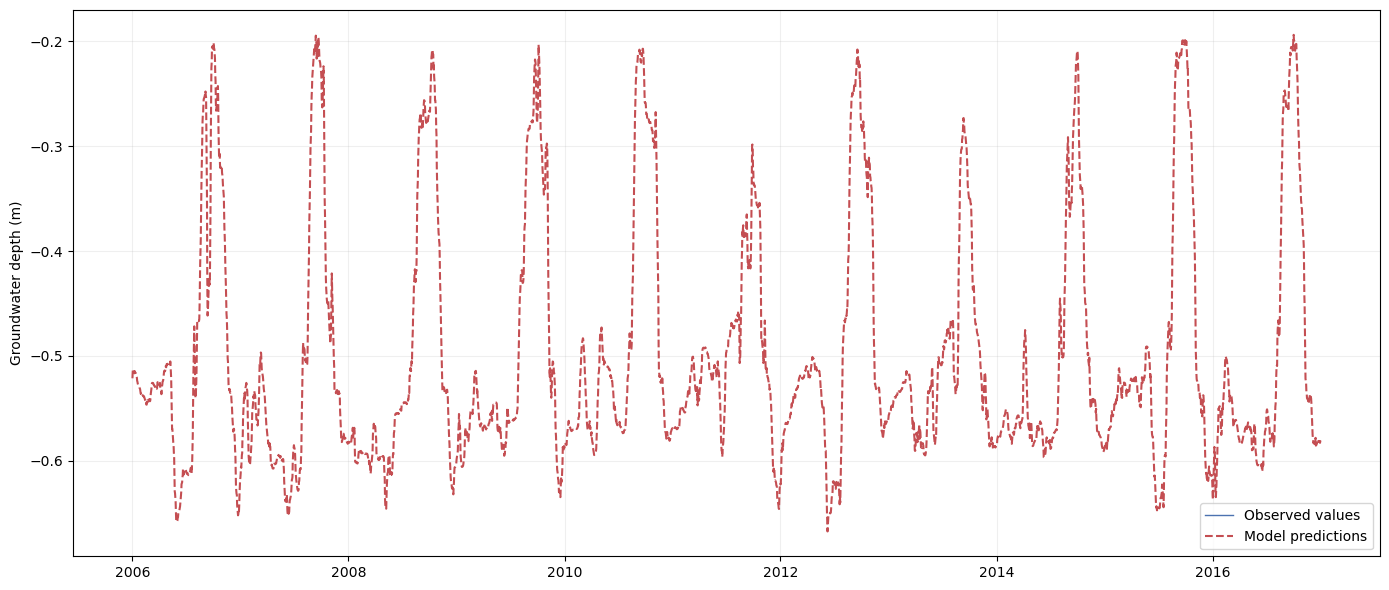

In [14]:
# PARA COMPARACION CON POZOS COLLAHUASI
sliced_L = slice_by_dates(applied1_L_past, '2006', '2016')
plot_timeseries_results(df=sliced_L)

LANDSAT


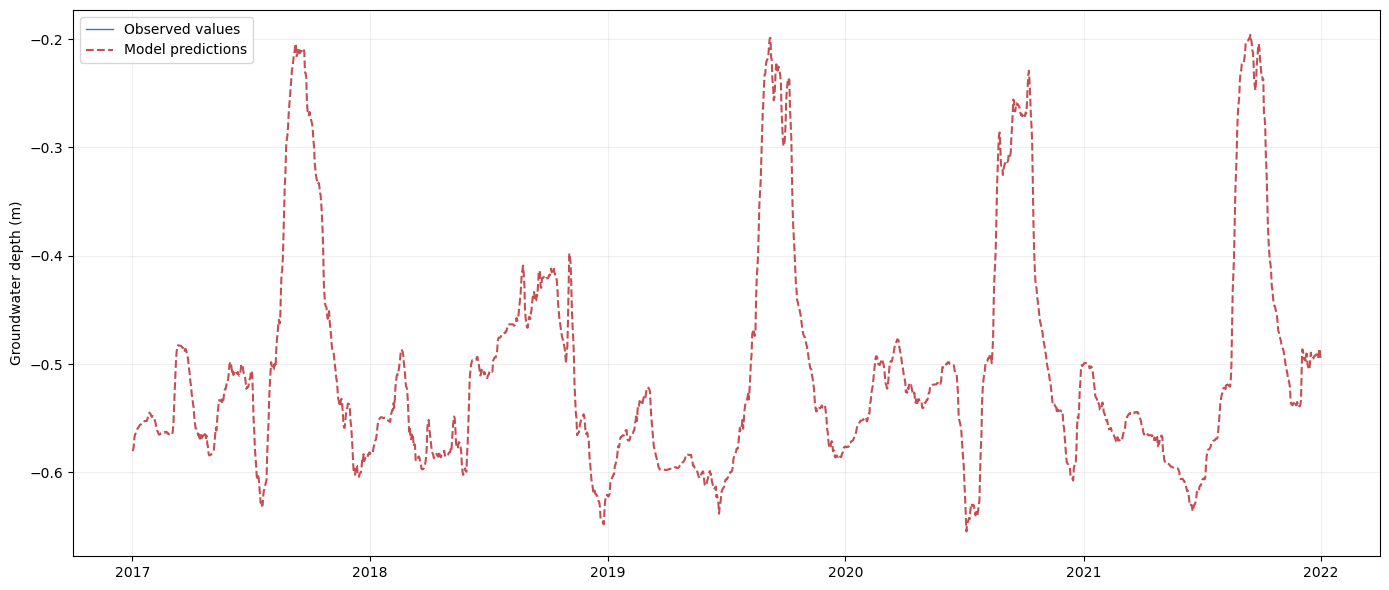

SENTINEL


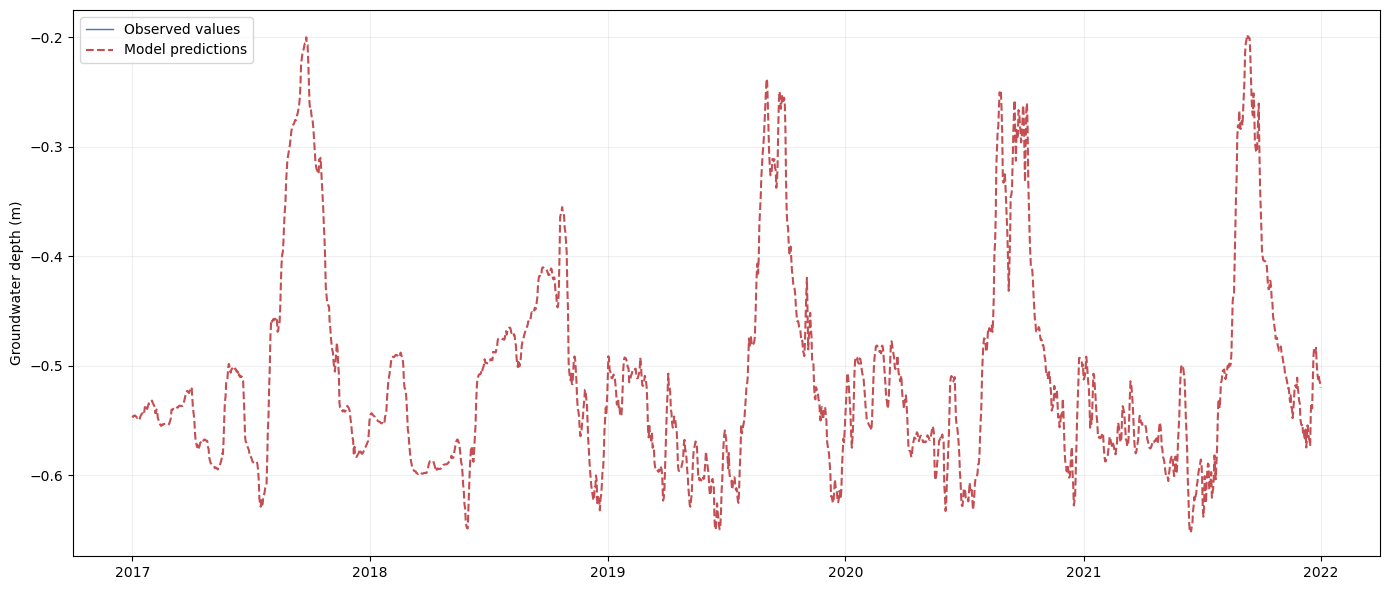

In [15]:
# COMPARACION S2 Y LANDSAT
sliced_L = slice_by_dates(applied1_L_past, '2017', '2021')
sliced_S2 = slice_by_dates(applied1_past, '2017', '2021')
print('LANDSAT')
plot_timeseries_results(df=sliced_L)
print('SENTINEL')
plot_timeseries_results(df=sliced_S2)

LANDSAT


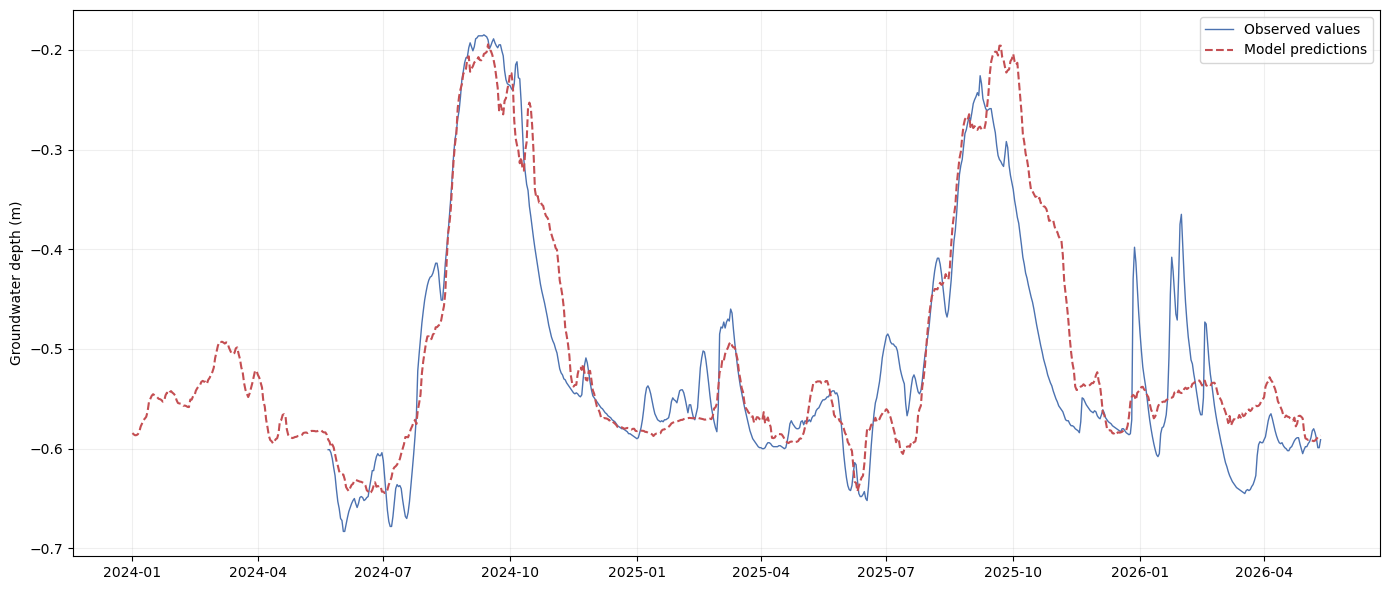

SENTINEL


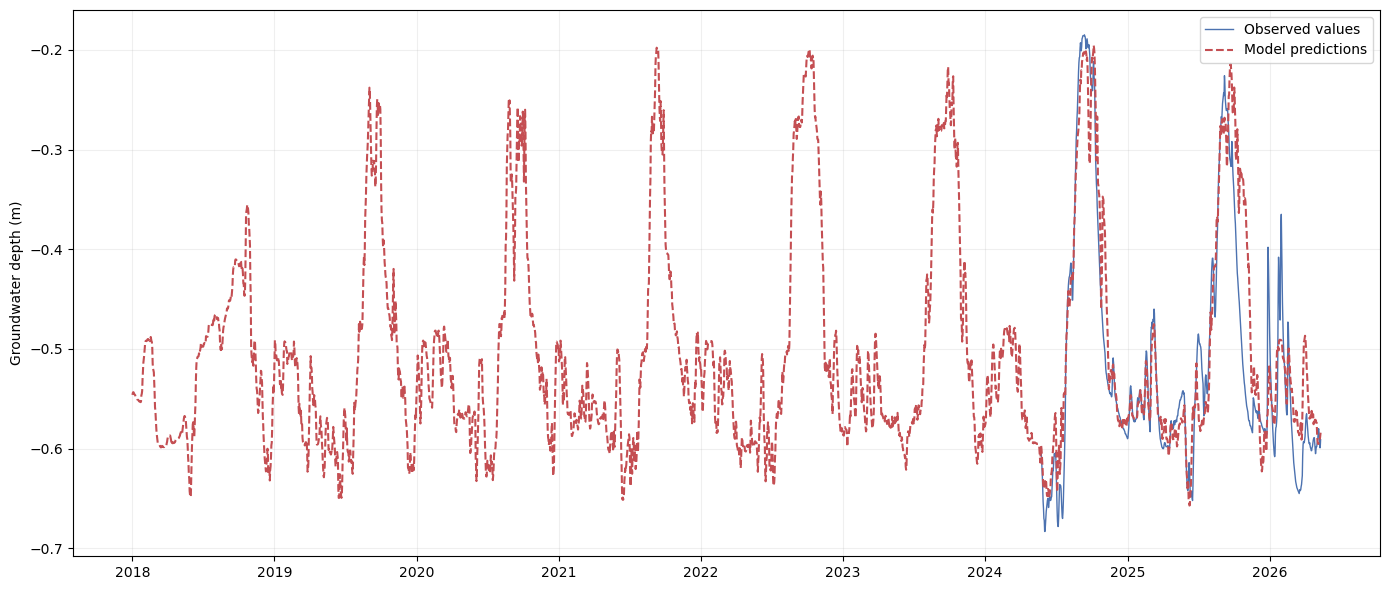

In [16]:
# COMPARACION S2 Y LANDSAT EN PERIODO CON REGISTROS
sliced_L = slice_by_dates(applied1_L_past, '2024', '2026')
sliced_S2 = slice_by_dates(applied1_past, '2018', '2026')
print('LANDSAT')
plot_timeseries_results(df=sliced_L)
print('SENTINEL')
plot_timeseries_results(df=sliced_S2)